## Importar librerias

In [95]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Cargar dataset

In [97]:
df_completo = pd.read_csv("bd_py.csv")

In [98]:
df_completo.head()

,r_def,t_loc_tri,ent,n_hog,sex,eda,cs_p12,cs_p13_1,e_con,ur,clase1,rama,ing7c,alta_educacion_ingreso_missing,pre_asa,tip_con_2,anios_esc,hrsocup,ing_x_hrs,mh_col
0,0,1,9,1,2,26,1,7,6,1,1,3,1,0,1,sin_contrato,16,36,0.00000,1
1,0,1,9,1,1,21,1,3,6,1,1,1,1,0,2,sin_contrato,9,33,45.45455,1
2,0,1,9,1,2,25,1,7,6,1,1,4,7,1,1,contrato,16,28,0.00000,0
3,0,1,9,1,1,30,1,3,5,1,1,4,2,0,1,contrato,9,40,50.00000,0
4,0,1,9,1,1,43,1,3,5,1,1,3,2,0,0,No_aplica,9,60,46.51163,1


# Data Cleaning

In [100]:
print(df_completo.shape)

(12138, 20)


In [101]:
df_completo.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12138 entries, 0 to 12137
Data columns (total 20 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   r_def                           12138 non-null  int64  
 1   t_loc_tri                       12138 non-null  int64  
 2   ent                             12138 non-null  int64  
 3   n_hog                           12138 non-null  int64  
 4   sex                             12138 non-null  int64  
 5   eda                             12138 non-null  int64  
 6   cs_p12                          12138 non-null  int64  
 7   cs_p13_1                        12138 non-null  int64  
 8   e_con                           12138 non-null  int64  
 9   ur                              12138 non-null  int64  
 10  clase1                          12138 non-null  int64  
 11  rama                            12138 non-null  int64  
 12  ing7c                           

In [102]:
#se crea un dataset con las variables que se utilizaran para el analsis
# Crear nuevo DataFrame eliminando columnas innecesarias
df = df_completo[
    [
        "t_loc_tri",
        "ent",
        "sex",
        "eda",
        "cs_p12",
        "cs_p13_1",
        "e_con",
        "ur",
        #"clase1",
        "rama",
        "ing7c",
        "alta_educacion_ingreso_missing",
        "tip_con_2",
        "anios_esc",
        "hrsocup",
        "ing_x_hrs",
        "mh_col"
    ]
].copy()
# Visualizar las columnas restantes
print(df.columns)

Index(['t_loc_tri', 'ent', 'sex', 'eda', 'cs_p12', 'cs_p13_1', 'e_con', 'ur',
       'rama', 'ing7c', 'alta_educacion_ingreso_missing', 'tip_con_2',
       'anios_esc', 'hrsocup', 'ing_x_hrs', 'mh_col'],
      dtype='object')


In [103]:
# revisar missings reales
df.isnull().sum()

t_loc_tri                         0
ent                               0
sex                               0
eda                               0
cs_p12                            0
cs_p13_1                          0
e_con                             0
ur                                0
rama                              0
ing7c                             0
alta_educacion_ingreso_missing    0
tip_con_2                         0
anios_esc                         0
hrsocup                           0
ing_x_hrs                         0
mh_col                            0
dtype: int64

In [104]:
#del EDA original resulto que algunas variables tienen outliers por lo que en la siguiente imagen se puede 
#validar los valores que son extremos y se tuvieron que omitir.
# - hrsocup
# - anios_esc	

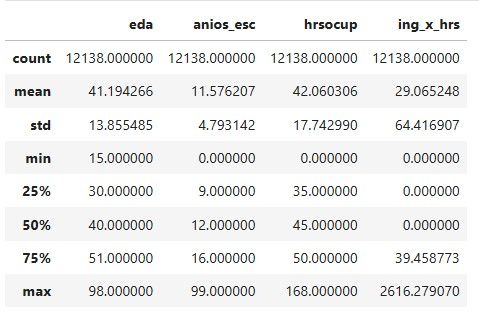

In [105]:
from IPython.display import Image, display

display(Image(filename='image1.jpg'))

In [106]:
df = df[df["anios_esc"] != 99]

In [107]:
df = df[df["hrsocup"] <= 100]

# Distribucion de target variable: INFORMALIDAD.

EL VALOR 1 = INFORMALES 

EL VALOR 0 = FORMALES

In [110]:
df["mh_col"].value_counts()

mh_col
1    6206
0    5906
Name: count, dtype: int64

In [111]:
df["mh_col"].value_counts(normalize=True) * 100

mh_col
1    51.238441
0    48.761559
Name: proportion, dtype: float64

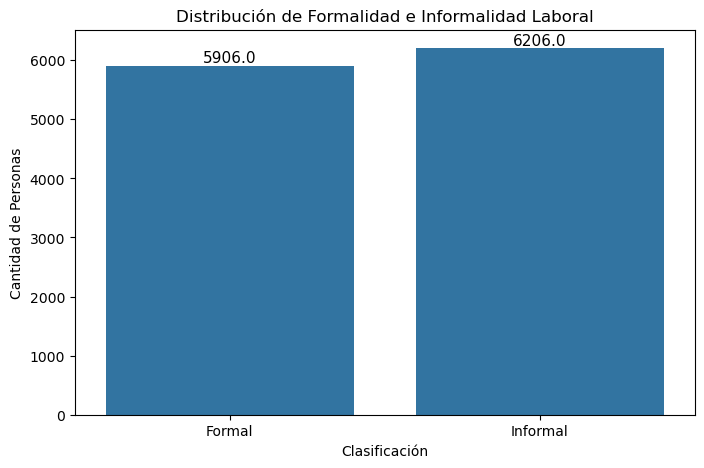

In [112]:

#creacion de grafica de distribucion de formalidad e informalidad
plt.figure(figsize=(8,5))

ax = sns.countplot(
    x="mh_col",
    data=df
)

plt.title("Distribución de Formalidad e Informalidad Laboral")
plt.xlabel("Clasificación")
plt.ylabel("Cantidad de Personas")

plt.xticks(
    [0,1],
    ["Formal", "Informal"]
)

# Agregar etiquetas
for p in ax.patches:
    ax.annotate(
        f'{p.get_height()}',
        (p.get_x() + p.get_width() / 2., p.get_height()),
        ha='center',
        va='bottom',
        fontsize=11
    )

plt.show()

# EDA

#### ANALISIS DE VARIABLES NUMERICAS

In [115]:

# CLASIFICACIÓN VARIABLES
categorical_vars = [
    "t_loc_tri",
    "ent",
    "sex",
    "cs_p12",
    "cs_p13_1",
    "e_con",
    "ur",
    "rama",
    "tip_con_2"
]

ordinal_vars = [
    "ing7c"
]

numeric_vars = [
    "eda",
    "anios_esc",
    "hrsocup",
    "ing_x_hrs"
]

binary_vars = [
    "mh_col",
    "alta_educacion_ingreso_missing"
]

In [116]:
df[numeric_vars].describe()

,eda,anios_esc,hrsocup,ing_x_hrs
count,12112.000000,12112.000000,12112.000000,12112.000000
mean,41.191298,11.497193,41.967801,29.100261
std,13.858330,4.007259,17.550045,64.475939
min,15.000000,0.000000,0.000000,0.000000
25%,30.000000,9.000000,35.000000,0.000000
50%,40.000000,12.000000,45.000000,0.000000
75%,51.000000,16.000000,50.000000,39.583330
max,98.000000,23.000000,98.000000,2616.279070


#### Scatterplot

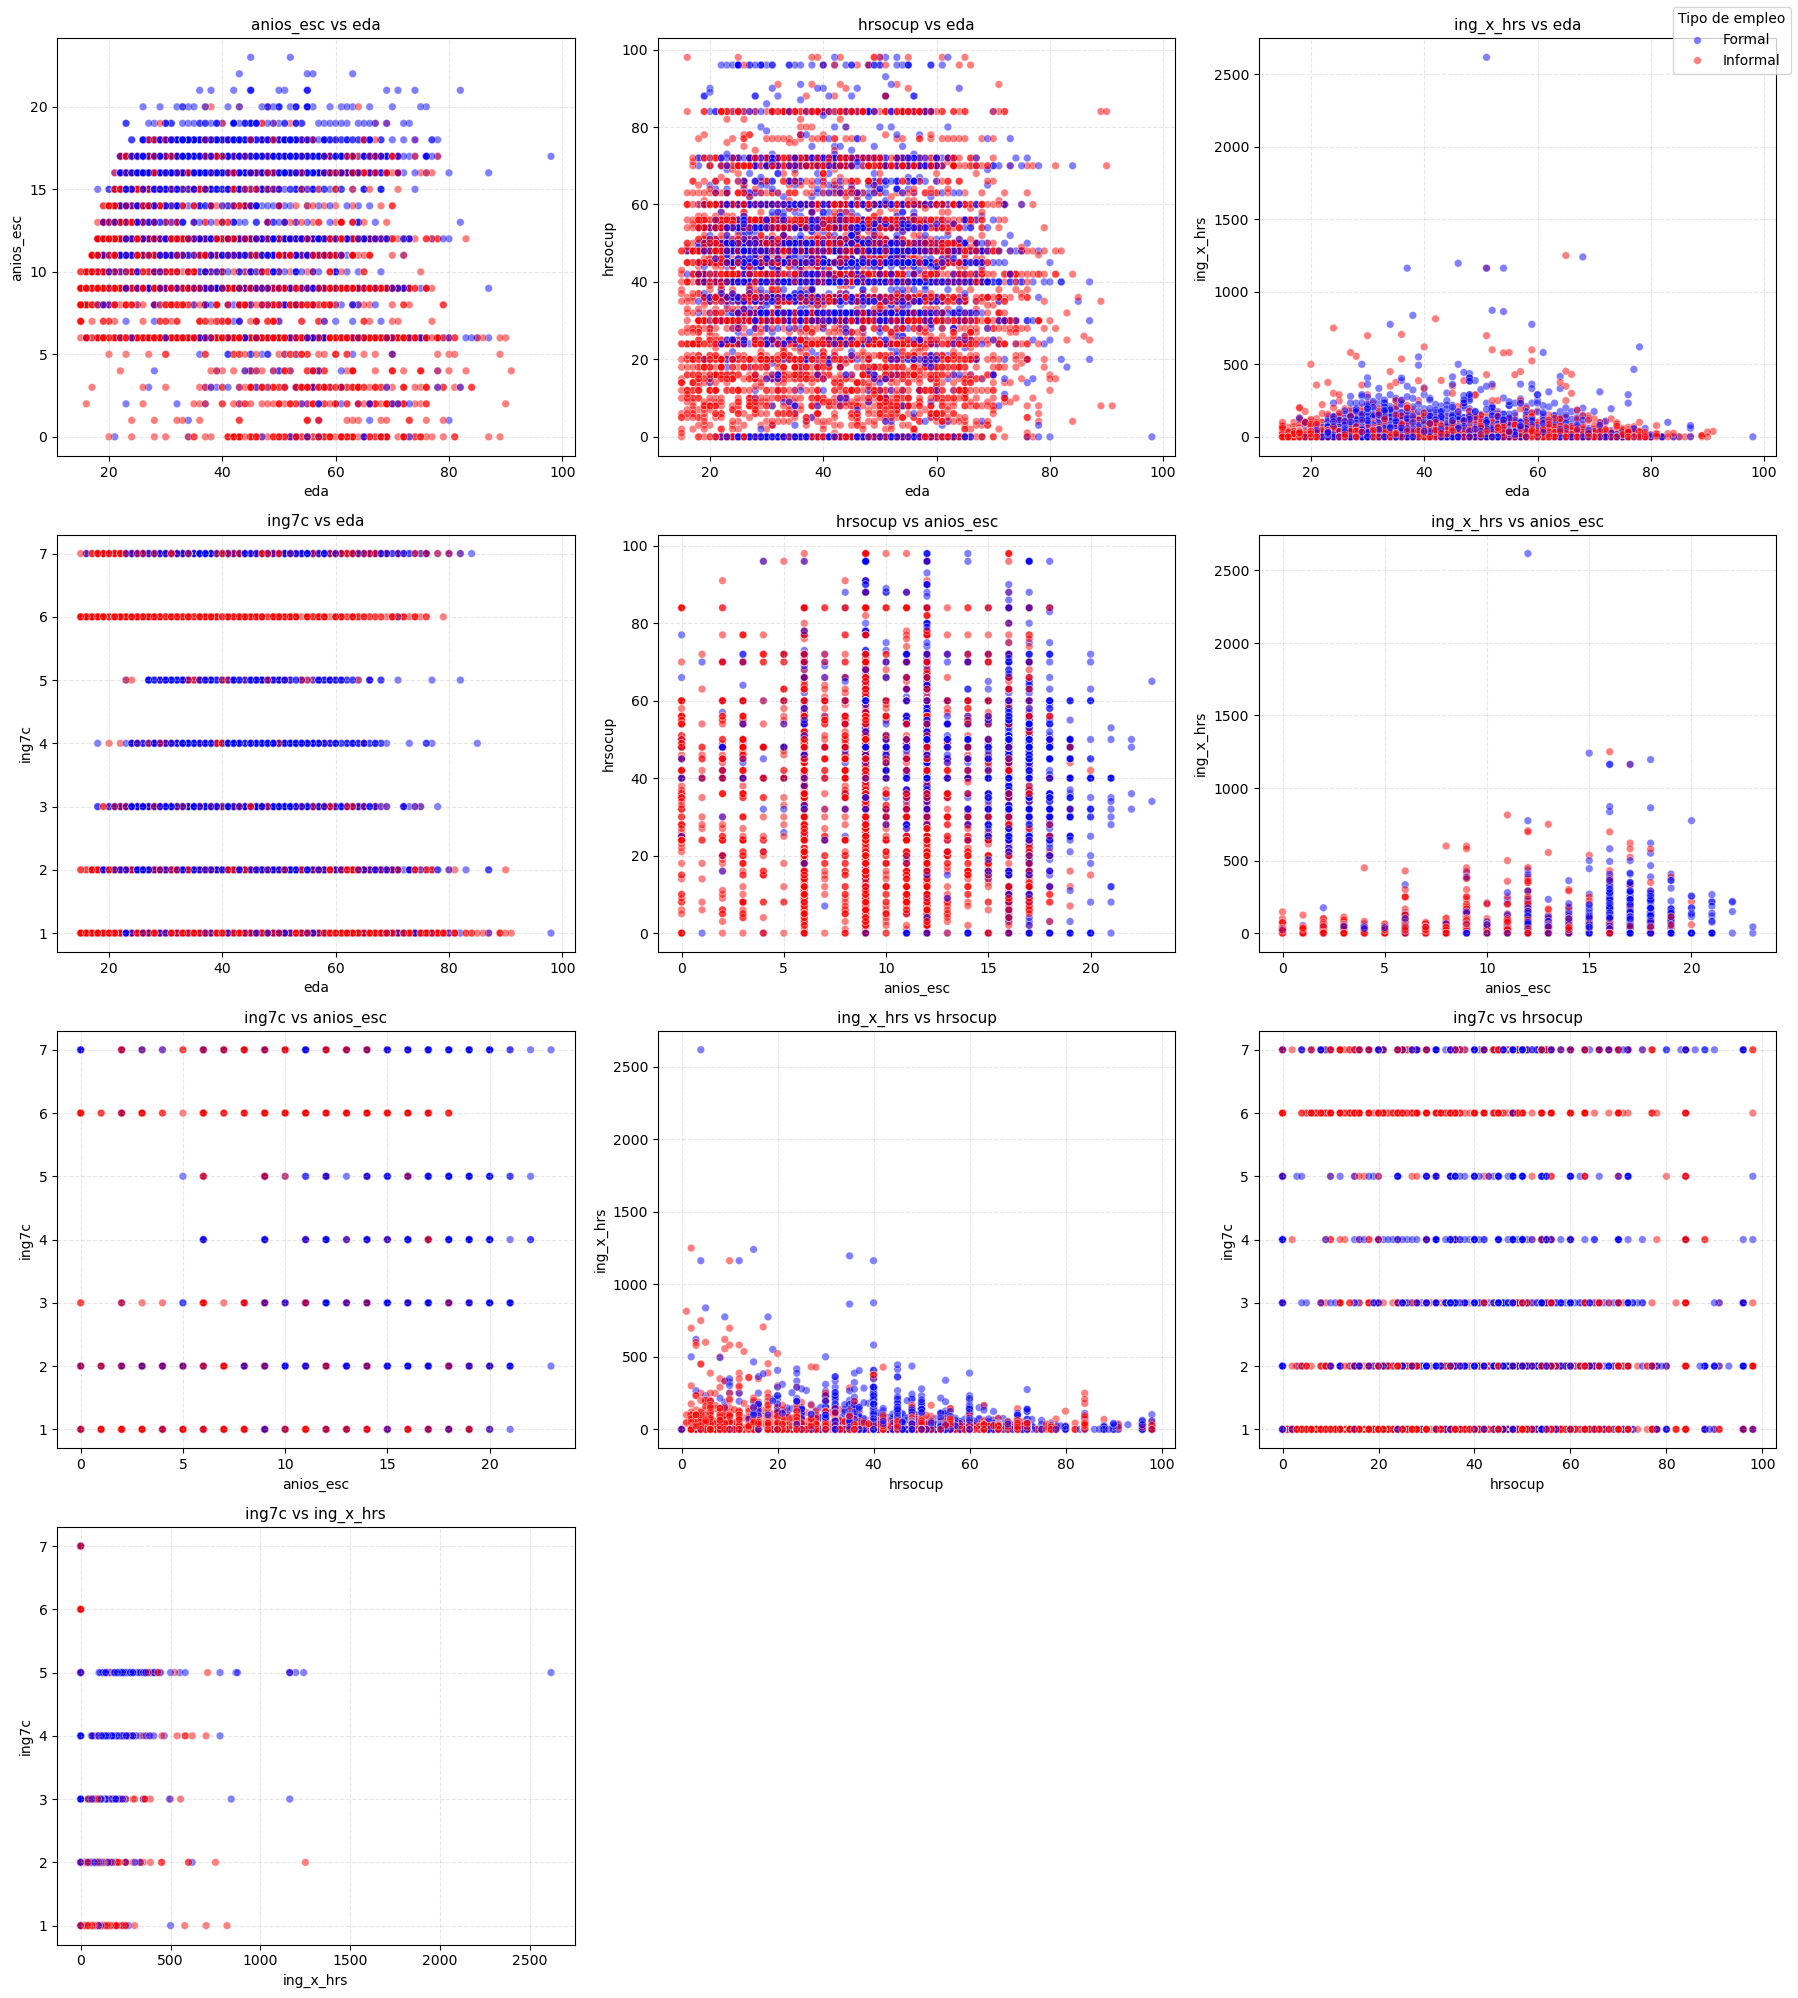

In [118]:
import matplotlib.pyplot as plt
import seaborn as sns
from itertools import combinations
import math


# VARIABLES

plot_vars = numeric_vars + ordinal_vars

# Crear combinaciones de 2 variables
comb_vars = list(combinations(plot_vars, 2))

# CONFIGURACION SUBPLOTS
n_cols = 3
n_rows = math.ceil(len(comb_vars) / n_cols)

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(18, 5 * n_rows)
)

axes = axes.flatten()

# CREAR GRAFICAS

for i, (x_var, y_var) in enumerate(comb_vars):

    sns.scatterplot(
        data=df,
        x=x_var,
        y=y_var,
        hue="mh_col",
        palette={0: "blue", 1: "red"},
        alpha=0.5,
        s=30,
        ax=axes[i]
    )

    axes[i].set_title(
        f"{y_var} vs {x_var}",
        fontsize=11
    )

    axes[i].grid(
        linestyle="--",
        alpha=0.3
    )

    # Eliminar leyendas repetidas
    axes[i].legend().remove()

handles, labels = axes[0].get_legend_handles_labels()

fig.legend(
    handles,
    ["Formal", "Informal"],
    title="Tipo de empleo",
    loc="upper right"
)


# ELIMINAR GRAFICAS VACIAS
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

# AJUSTAR ESPACIADO

plt.tight_layout()

plt.show()

#### Histogramas

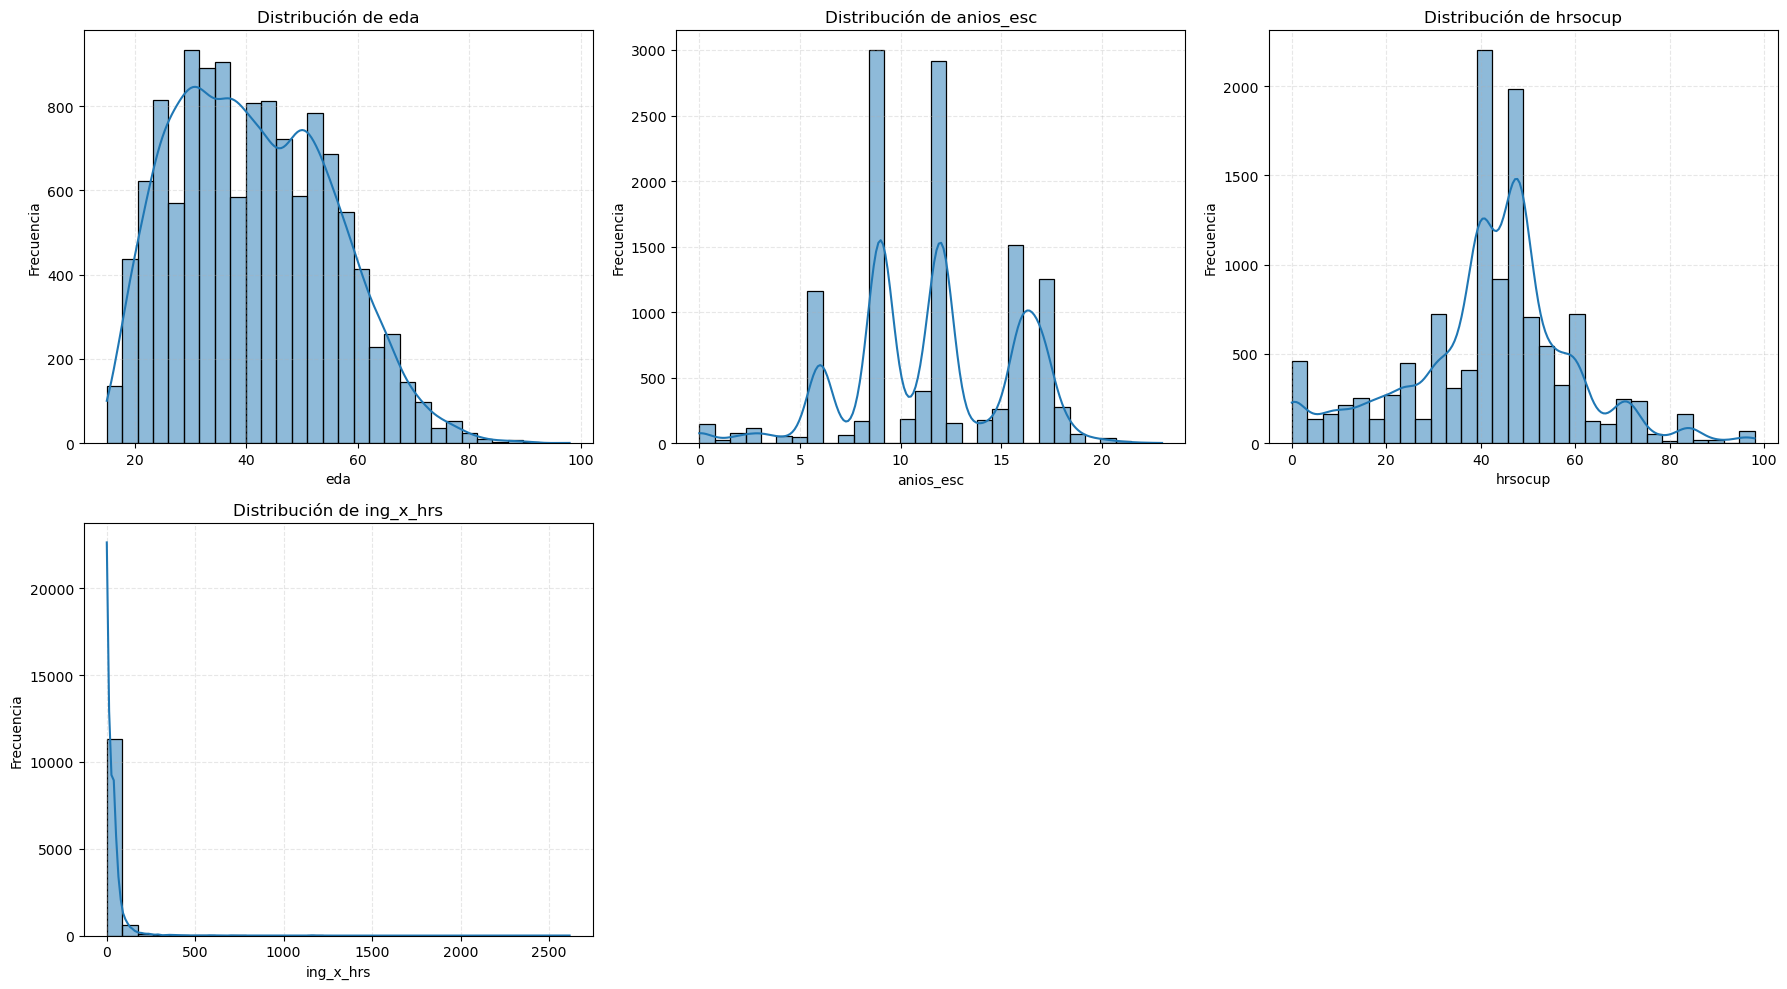

In [120]:
import matplotlib.pyplot as plt
import seaborn as sns
import math


# HISTOGRAMAS EN SUBPLOTS 


# Configuración
n_cols = 3
n_rows = math.ceil(len(numeric_vars) / n_cols)

# Crear figura y ejes
fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(18, 5 * n_rows)
)

# Convertir axes en lista plana
axes = axes.flatten()

# CREAR HISTOGRAMAS

for i, col in enumerate(numeric_vars):

    sns.histplot(
        df[col],
        bins=30,
        kde=True,
        ax=axes[i]
    )

    axes[i].set_title(
        f"Distribución de {col}",
        fontsize=12
    )

    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Frecuencia")

    axes[i].grid(
        linestyle="--",
        alpha=0.3
    )


# ELIMINAR GRAFICAS VACIAS
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

# AJUSTAR ESPACIADO
plt.tight_layout()
plt.show()

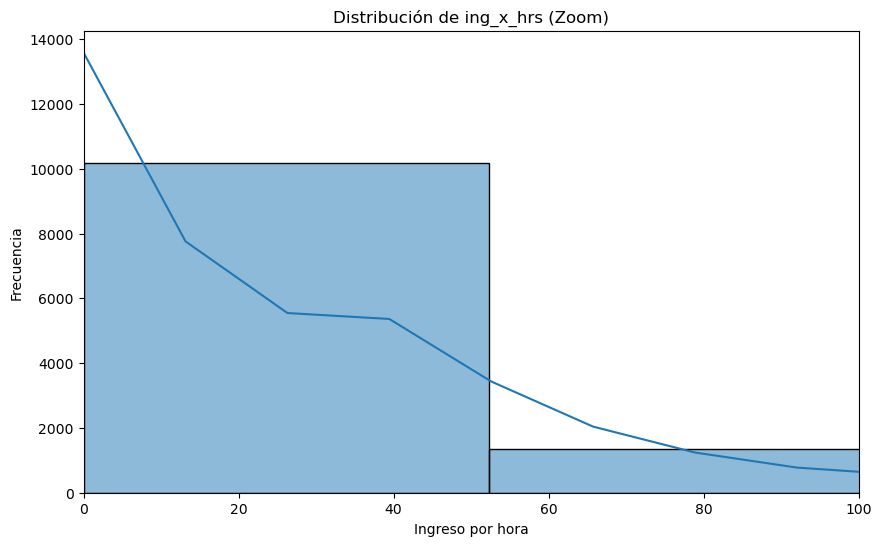

In [121]:
plt.figure(figsize=(10,6))

sns.histplot(
    df["ing_x_hrs"],
    bins=50,
    kde=True
)

# Zoom eje X
plt.xlim(0, 100)

plt.title("Distribución de ing_x_hrs (Zoom)")
plt.xlabel("Ingreso por hora")
plt.ylabel("Frecuencia")

plt.show()

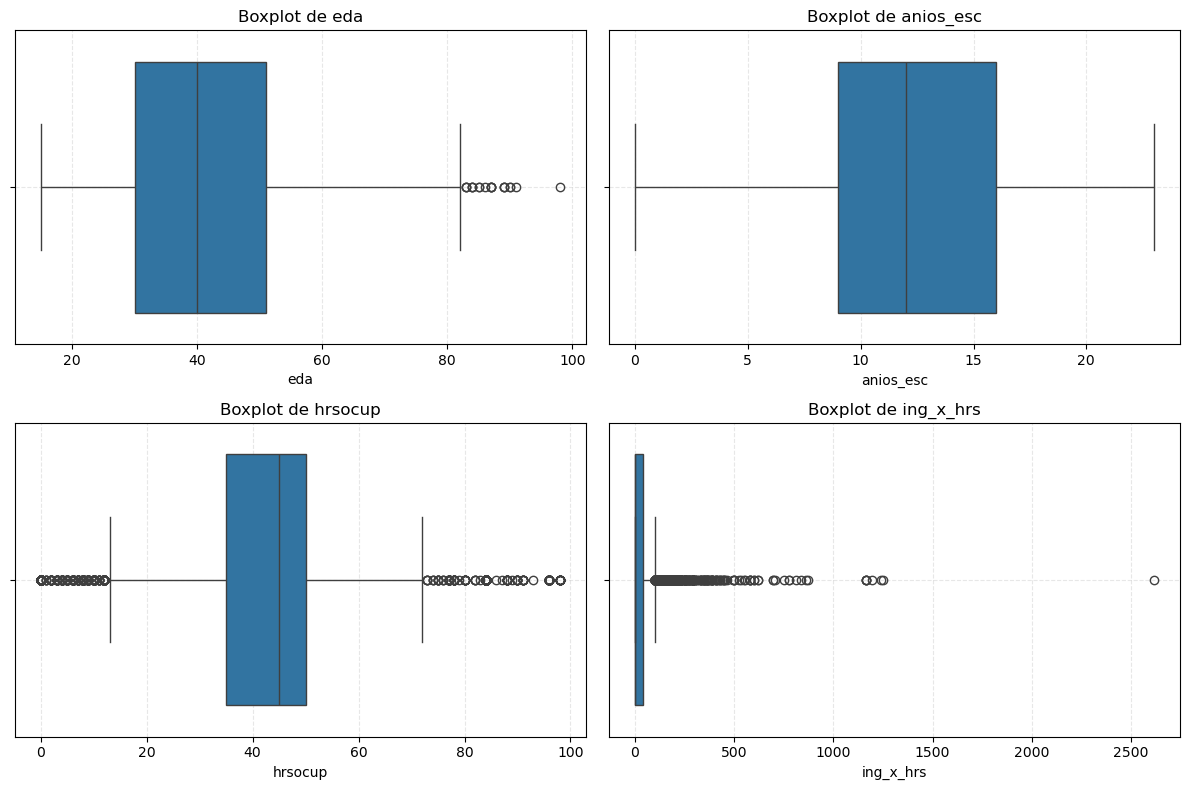

In [122]:
import matplotlib.pyplot as plt
import seaborn as sns
import math


# CONFIGURACION DINAMICA
n_cols = 2
n_rows = math.ceil(len(numeric_vars) / n_cols)

# Crear subplots
fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(12, 4 * n_rows)
)

# Convertir axes en lista plana
axes = axes.flatten()

# CREAR BOXPLOTS
for i, col in enumerate(numeric_vars):

    sns.boxplot(
        x=df[col],
        ax=axes[i]
    )

    axes[i].set_title(
        f"Boxplot de {col}",
        fontsize=12
    )

    axes[i].set_xlabel(col)

    axes[i].grid(
        linestyle="--",
        alpha=0.3
    )


# ELIMINAR GRAFICAS VACIAS
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])


# AJUSTAR ESPACIADO

plt.tight_layout()
plt.show()

#### ANALISIS DE VARIABLES CATEGORICAS

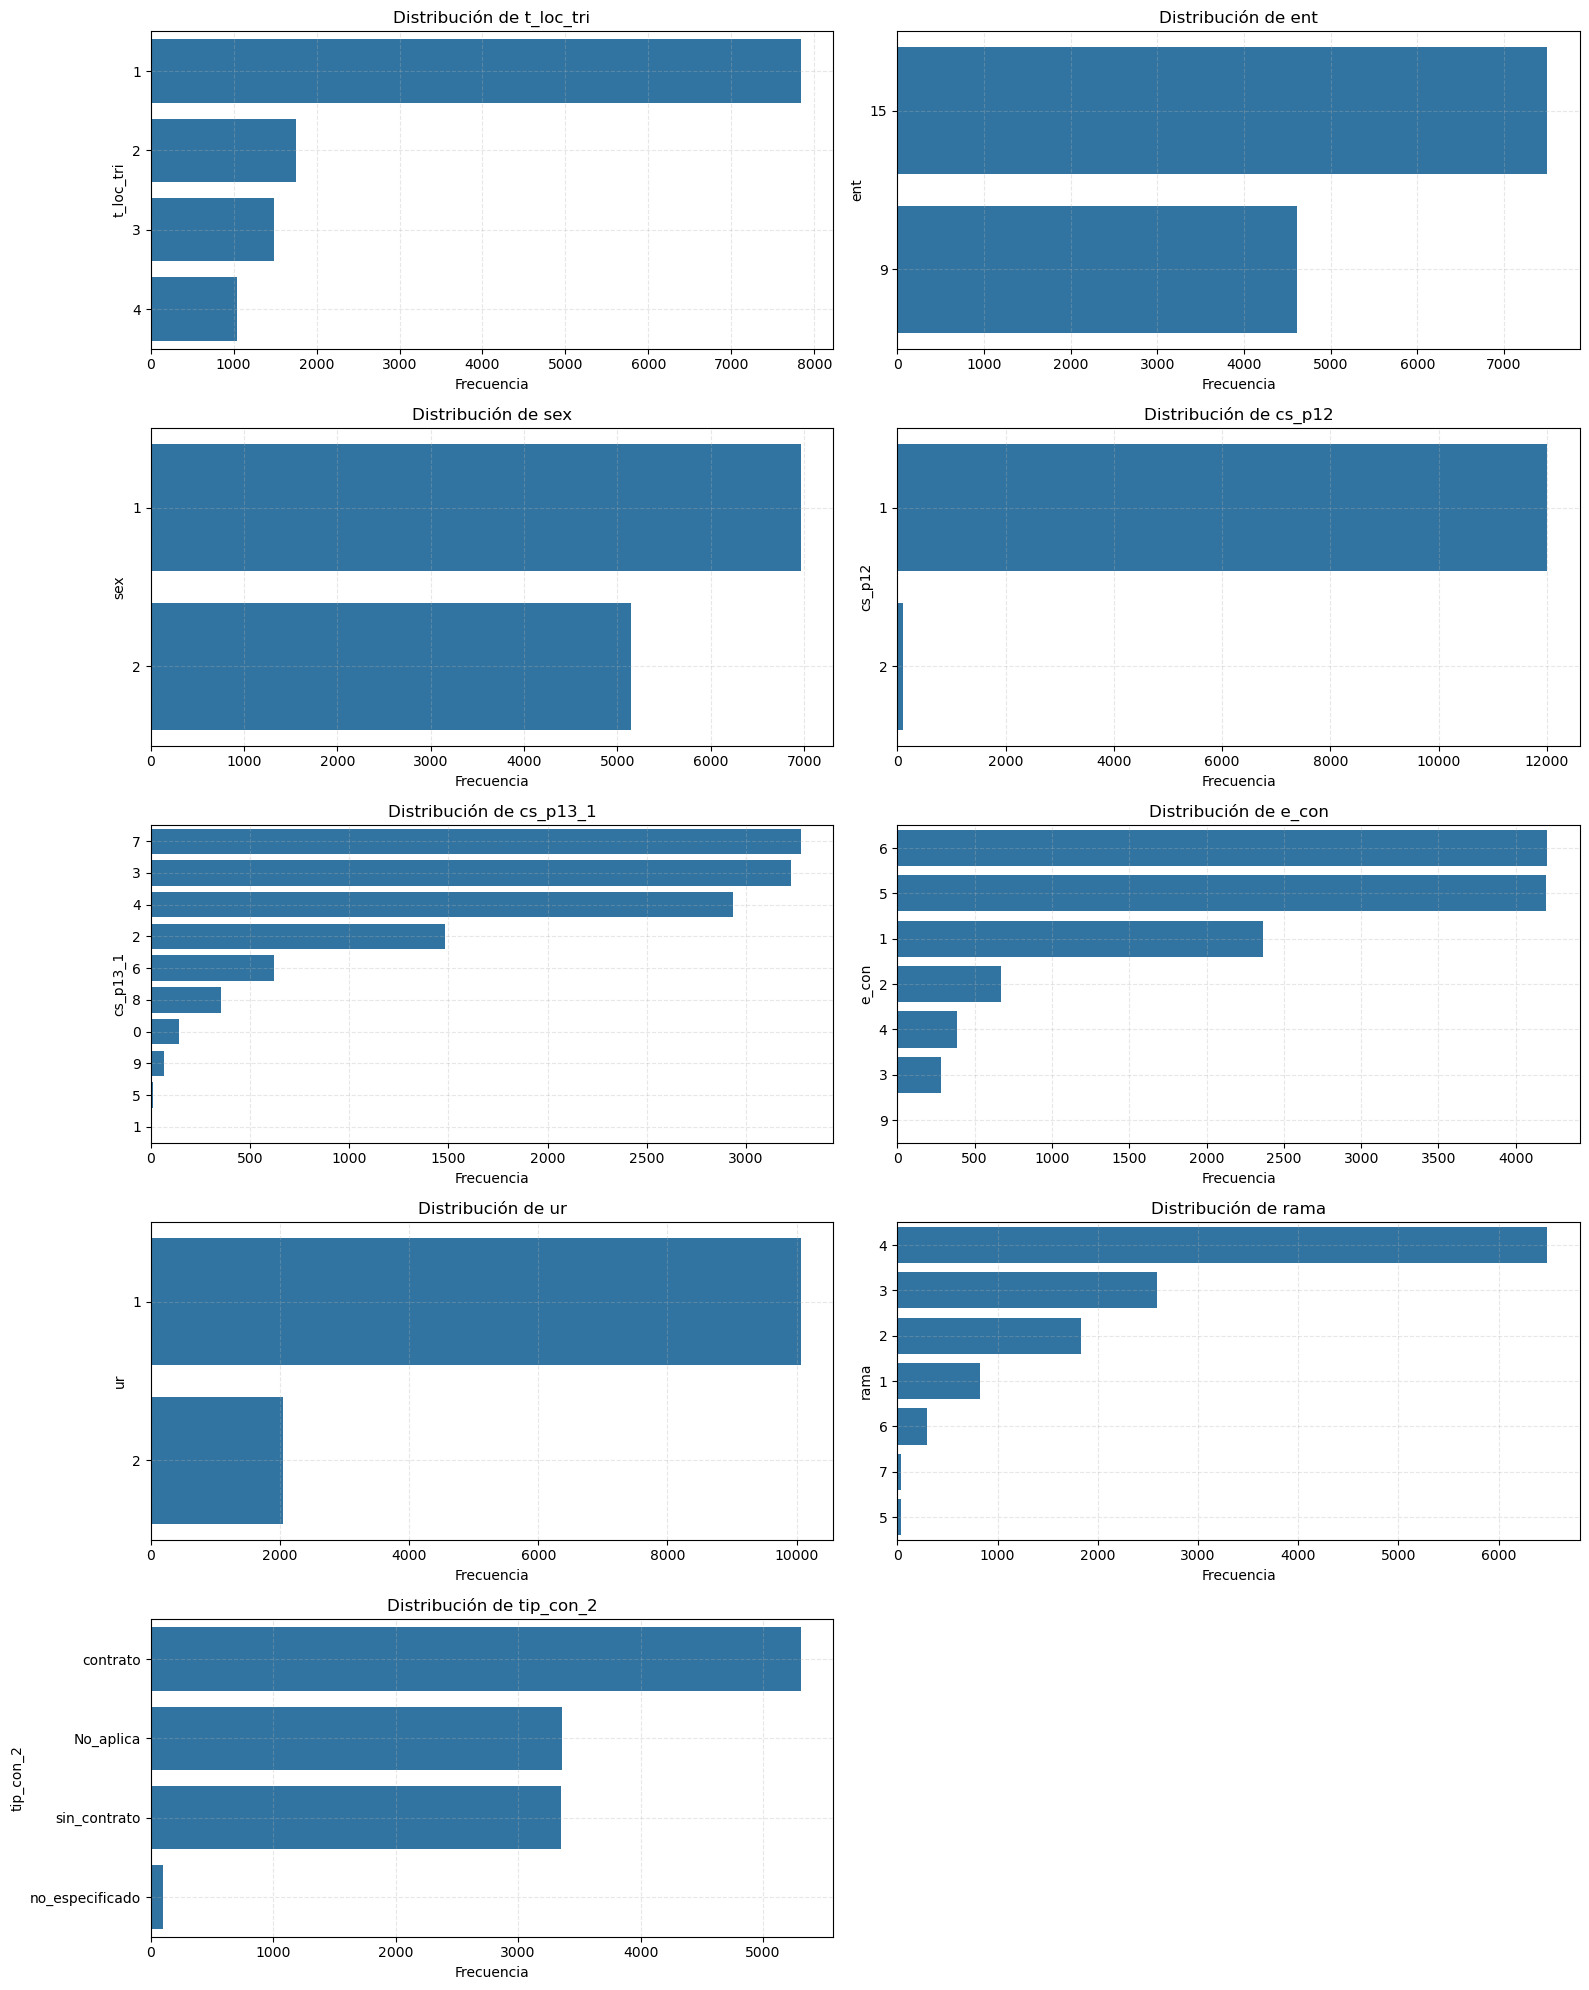

In [124]:
import matplotlib.pyplot as plt
import seaborn as sns
import math


# COUNTPLOTS PARA VARIABLES CATEGORICAS

# Configuración
n_cols = 2
n_rows = math.ceil(len(categorical_vars) / n_cols)

# Crear figura y subplots
fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(16, 4 * n_rows)
)

# Convertir axes en lista plana
axes = axes.flatten()

#  GRAFICAS

for i, col in enumerate(categorical_vars):

    # Ordenar categorías por frecuencia
    order = df[col].value_counts().index

    sns.countplot(
        data=df,
        y=col,
        order=order,
        ax=axes[i]
    )

    axes[i].set_title(
        f"Distribución de {col}",
        fontsize=12
    )

    axes[i].set_xlabel("Frecuencia")
    axes[i].set_ylabel(col)

    axes[i].grid(
        linestyle="--",
        alpha=0.3
    )

# ELIMINAR GRAFICAS VACIAS
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])


# AJUSTAR ESPACIADO
plt.tight_layout()
plt.show()

# ANALISIS DE RELACIONES CON TARGET VARIABLE DE INFORMALIDAD

### Escolaridad vs informalidad

<Figure size 1000x600 with 0 Axes>

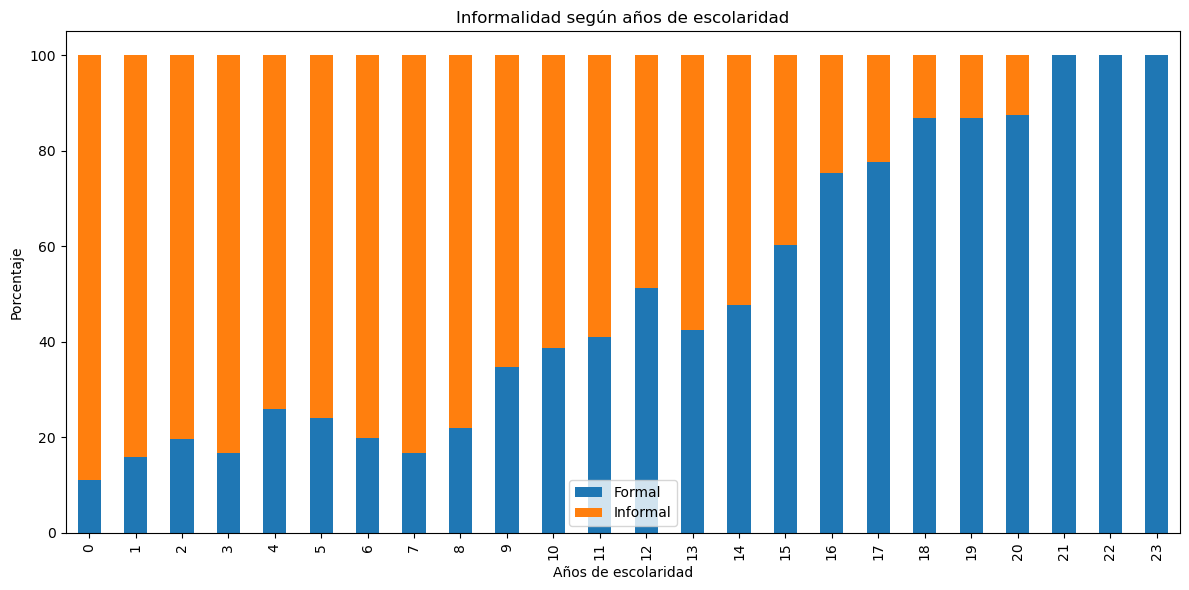

In [127]:
plt.figure(figsize=(10,6))

tabla_esc = pd.crosstab(
    df["anios_esc"],
    df["mh_col"],
    normalize='index'
) * 100

tabla_esc.plot(
    kind="bar",
    stacked=True,
    figsize=(12,6)
)

plt.title("Informalidad según años de escolaridad")
plt.xlabel("Años de escolaridad")
plt.ylabel("Porcentaje")

plt.legend(
    ["Formal", "Informal"]
)

plt.tight_layout()
plt.show()

## Tipo de contrato vs informalidad

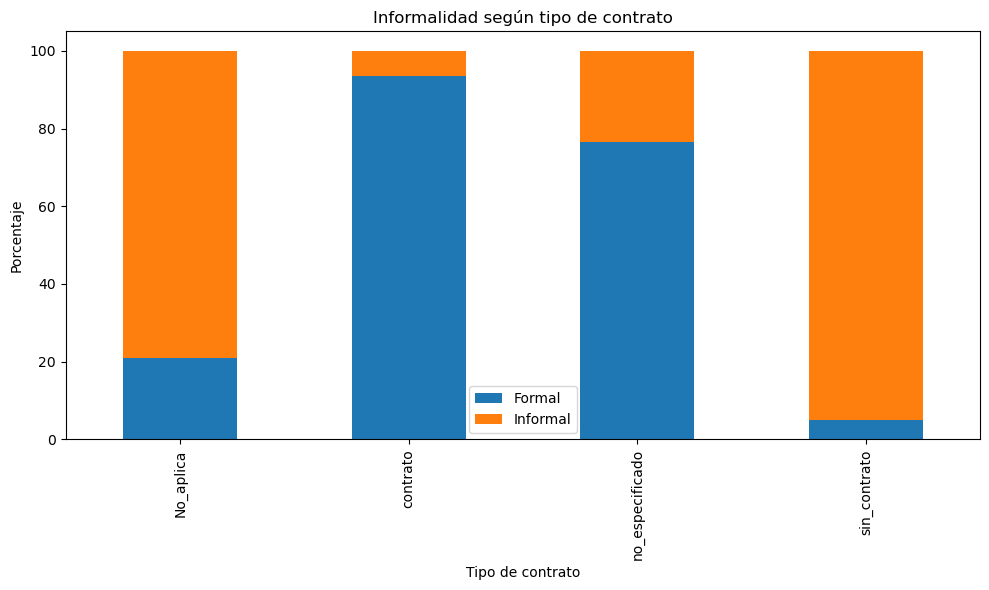

In [129]:

tabla_contrato = pd.crosstab(
    df["tip_con_2"],
    df["mh_col"],
    normalize='index'
) * 100

tabla_contrato.plot(
    kind="bar",
    stacked=True,
    figsize=(10,6)
)

plt.title("Informalidad según tipo de contrato")
plt.xlabel("Tipo de contrato")
plt.ylabel("Porcentaje")

plt.legend(
    ["Formal", "Informal"]
)

plt.tight_layout()
plt.show()

## Sexo vs informalidad

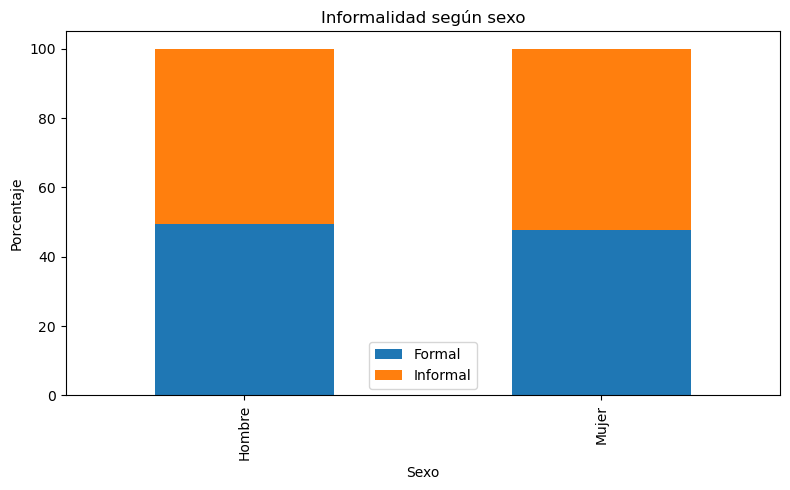

In [131]:
df["sex"] = df["sex"].replace({
    1:"Hombre",
    2:"Mujer"
})

tabla_sexo = pd.crosstab(
    df["sex"],
    df["mh_col"],
    normalize='index'
) * 100

tabla_sexo.plot(
    kind="bar",
    stacked=True,
    figsize=(8,5)
)

plt.title("Informalidad según sexo")
plt.xlabel("Sexo")
plt.ylabel("Porcentaje")

plt.legend(
    ["Formal", "Informal"]
)

plt.tight_layout()
plt.show()

## Rama económica vs informalidad

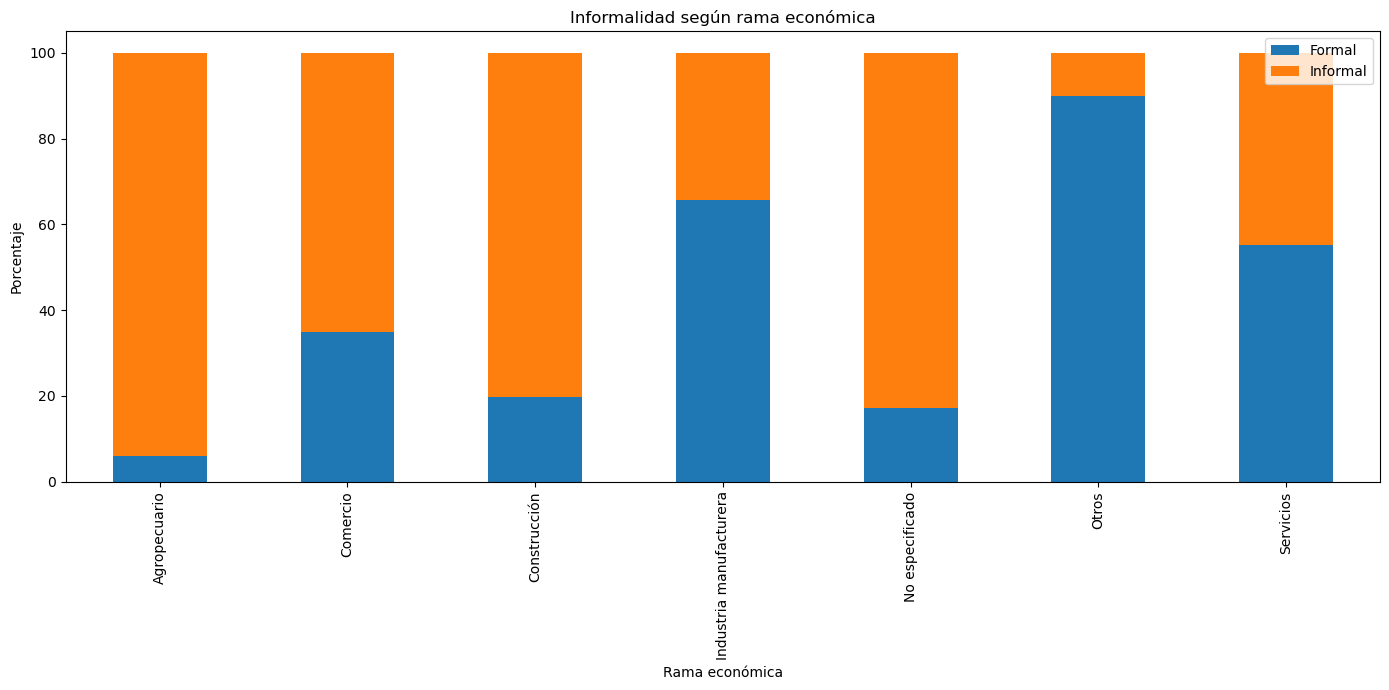

In [133]:
df["rama"] = df["rama"].replace({
    0: "No aplica",
    1: "Construcción",
    2: "Industria manufacturera",
    3: "Comercio",
    4: "Servicios",
    5: "Otros",
    6: "Agropecuario",
    7: "No especificado"
})

tabla_rama = pd.crosstab(
    df["rama"],
    df["mh_col"],
    normalize='index'
) * 100

tabla_rama.plot(
    kind="bar",
    stacked=True,
    figsize=(14,7)
)

plt.title("Informalidad según rama económica")
plt.xlabel("Rama económica")
plt.ylabel("Porcentaje")

plt.legend(
    ["Formal", "Informal"]
)

plt.tight_layout()
plt.show()

# ANALISIS DE CORRELACION

## Numericas

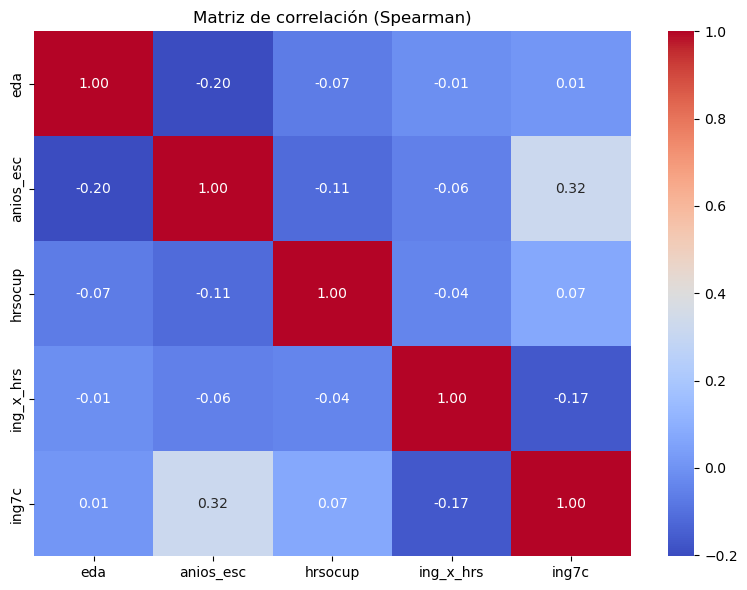

In [136]:
import matplotlib.pyplot as plt
import seaborn as sns


# VARIABLES NUMÉRICAS

numeric_vars = [
    "eda",
    "anios_esc",
    "hrsocup",
    "ing_x_hrs",
    "ing7c"
]

# MATRIZ DE CORRELACIÓN
corr_matrix = df[numeric_vars].corr(method="spearman")


# HEATMAP
plt.figure(figsize=(8,6))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Matriz de correlación (Spearman)")

plt.tight_layout()
plt.show()

In [137]:
#Correlacion de las variables con la target variable
#1= informal 
corr_target = df[
    numeric_vars + ["mh_col"]
].corr(method="spearman")

print(corr_target["mh_col"].sort_values(ascending=False))

mh_col       1.000000
ing_x_hrs    0.040937
eda          0.015744
hrsocup     -0.074236
ing7c       -0.285781
anios_esc   -0.399401
Name: mh_col, dtype: float64


## Categoricas.

XI 2= p < 0.05, existe asociación estadísticamente significativa. Existe asociación.

CRAMÉR'S V = qué tan fuerte es la asociación

| Cramer's V | Interpretación |
|---|---|
| < 0.1 | Muy débil |
| 0.1 – 0.3 | Débil |
| 0.3 – 0.5 | Moderada |
| > 0.5 | Fuerte |

In [140]:
import pandas as pd
import numpy as np
from scipy.stats import chi2_contingency

# VARIABLES CATEGÓRICAS A EVALUAR
categorical_vars = [
    "t_loc_tri",
    "ent",
    "sex",
    "cs_p12",
    "cs_p13_1",
    "e_con",
    "ur",
    "rama",
    "ing7c",
    "tip_con_2",
    "alta_educacion_ingreso_missing"
]

# VARIABLE TARGET
target = "mh_col"

results = []


# LOOP CHI2 + CRAMER'S V

for var in categorical_vars:

    # Tabla contingencia
    tabla = pd.crosstab(df[var], df[target])

    # Chi-cuadrada
    chi2, p, dof, expected = chi2_contingency(tabla)

    # Total observaciones
    n = tabla.sum().sum()

    # Cramer's V
    cramers_v = np.sqrt(
        chi2 / (n * (min(tabla.shape) - 1))
    )

    # Guardar resultados
    results.append({
        "Variable": var,
        "Chi2": round(chi2, 2),
        "p-value": round(p, 5),
        "Cramers_V": round(cramers_v, 3)
    })


# RESULTADOS FINALES
results_df = pd.DataFrame(results)

# Ordenar por fuerza asociación
results_df = results_df.sort_values(
    by="Cramers_V",
    ascending=False
)

# Mostrar resultados
print(results_df)

                          Variable     Chi2  p-value  Cramers_V
9                        tip_con_2  7866.18  0.00000      0.806
8                            ing7c  1994.89  0.00000      0.406
4                         cs_p13_1  1853.37  0.00000      0.391
7                             rama  1052.69  0.00000      0.295
10  alta_educacion_ingreso_missing   637.96  0.00000      0.230
0                        t_loc_tri   342.33  0.00000      0.168
6                               ur   290.69  0.00000      0.155
5                            e_con    70.01  0.00000      0.076
3                           cs_p12    65.42  0.00000      0.073
1                              ent    19.88  0.00001      0.041
2                              sex     2.95  0.08563      0.016


# Feature Engineering para modelo Regresion Logistica

Considerando el analisis estadistico y el EDA, se han decidido eliminar las variables menos significativas y hacer transformacion de algunas variables.

Se haran dos modelos de Regresion Logistica, ya que se sospecha de Data Leakage de la variable "tipo de contrato".

In [143]:
# Partir del df base
df_fe = df.copy()

# 1. ELIMINAR VARIABLES QUE NO SE USAN EN NINGÚN MODELO


cols_eliminar = ['ent', 'sex', 'cs_p12', 'e_con']
df_fe = df_fe.drop(columns=cols_eliminar, errors='ignore')

**FEATURE ENGINEERING**

In [145]:
# se aplica logaritmo a la variable de ing_x_hrs derivado de que tiene valores extremos que podrian cambiar el peso de su importancia en el modelo
df_fe['ing_x_hrs_log'] = np.log1p(df_fe['ing_x_hrs'])
df_fe = df_fe.drop(columns=['ing_x_hrs'])

# eda²
#agrega eda² como feature adicional para capturar no-linealidad en la regresión logística:
df_fe['eda2'] = df_fe['eda'] ** 2

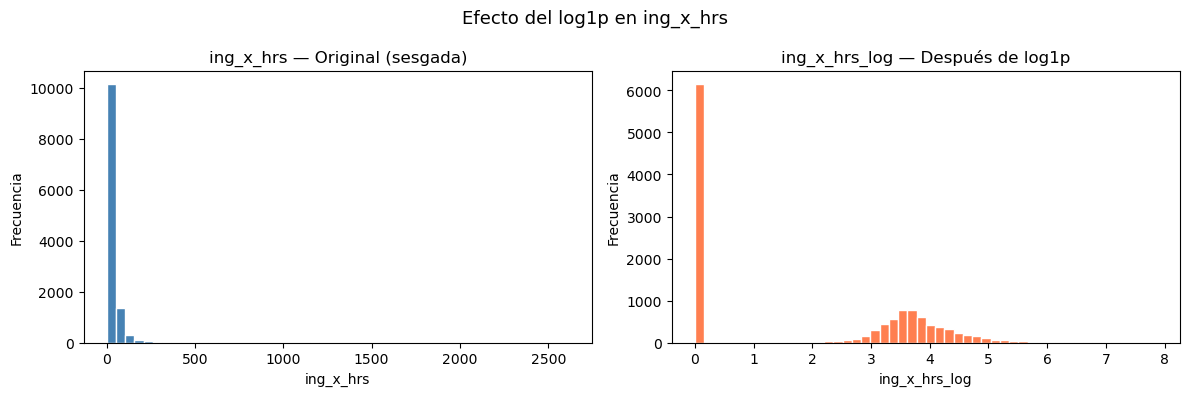

In [146]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Original (antes del log) - recuperar del df original
axes[0].hist(df['ing_x_hrs'], bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('ing_x_hrs — Original (sesgada)')
axes[0].set_xlabel('ing_x_hrs')
axes[0].set_ylabel('Frecuencia')

# Log1p
axes[1].hist(df_fe['ing_x_hrs_log'], bins=50, color='coral', edgecolor='white')
axes[1].set_title('ing_x_hrs_log — Después de log1p')
axes[1].set_xlabel('ing_x_hrs_log')
axes[1].set_ylabel('Frecuencia')

plt.suptitle('Efecto del log1p en ing_x_hrs', fontsize=13)
plt.tight_layout()
plt.show()

**DUMMIES**

In [148]:
cols_dummies = ['t_loc_tri', 'cs_p13_1', 'ur', 'rama', 'ing7c', 'tip_con_2']
df_fe = pd.get_dummies(df_fe, columns=cols_dummies, drop_first=True)

**ESCALAR NUMÉRICAS**

In [150]:
from sklearn.preprocessing import StandardScaler
cols_escalar = ['eda', 'eda2', 'anios_esc', 'hrsocup', 'ing_x_hrs_log']
scaler = StandardScaler()
df_fe[cols_escalar] = scaler.fit_transform(df_fe[cols_escalar])


# VERIFICAR
print(f"Shape df_fe: {df_fe.shape}")
print(f"\nColumnas:")
print(df_fe.columns.tolist())

Shape df_fe: (12112, 35)

Columnas:
['eda', 'alta_educacion_ingreso_missing', 'anios_esc', 'hrsocup', 'mh_col', 'ing_x_hrs_log', 'eda2', 't_loc_tri_2', 't_loc_tri_3', 't_loc_tri_4', 'cs_p13_1_1', 'cs_p13_1_2', 'cs_p13_1_3', 'cs_p13_1_4', 'cs_p13_1_5', 'cs_p13_1_6', 'cs_p13_1_7', 'cs_p13_1_8', 'cs_p13_1_9', 'ur_2', 'rama_Comercio', 'rama_Construcción', 'rama_Industria manufacturera', 'rama_No especificado', 'rama_Otros', 'rama_Servicios', 'ing7c_2', 'ing7c_3', 'ing7c_4', 'ing7c_5', 'ing7c_6', 'ing7c_7', 'tip_con_2_contrato', 'tip_con_2_no_especificado', 'tip_con_2_sin_contrato']


In [151]:
# Identificar columnas de tip_con_2 (las dummies generadas)
cols_tip_con_2 = [col for col in df_fe.columns if 'tip_con_2' in col]
print("Columnas de tip_con_2 a eliminar:")
print(cols_tip_con_2)

# Crear df sin contrato
df_RL_sinc = df_fe.drop(columns=cols_tip_con_2)

print(f"\nShape df_RL_sinc: {df_RL_sinc.shape}")
print(f"\nColumnas:")
print(df_RL_sinc.columns.tolist())

Columnas de tip_con_2 a eliminar:
['tip_con_2_contrato', 'tip_con_2_no_especificado', 'tip_con_2_sin_contrato']

Shape df_RL_sinc: (12112, 32)

Columnas:
['eda', 'alta_educacion_ingreso_missing', 'anios_esc', 'hrsocup', 'mh_col', 'ing_x_hrs_log', 'eda2', 't_loc_tri_2', 't_loc_tri_3', 't_loc_tri_4', 'cs_p13_1_1', 'cs_p13_1_2', 'cs_p13_1_3', 'cs_p13_1_4', 'cs_p13_1_5', 'cs_p13_1_6', 'cs_p13_1_7', 'cs_p13_1_8', 'cs_p13_1_9', 'ur_2', 'rama_Comercio', 'rama_Construcción', 'rama_Industria manufacturera', 'rama_No especificado', 'rama_Otros', 'rama_Servicios', 'ing7c_2', 'ing7c_3', 'ing7c_4', 'ing7c_5', 'ing7c_6', 'ing7c_7']


## Modelo 1. Regresión Logistica

Sin incluir tip_con_2

In [153]:
from sklearn.model_selection import train_test_split

X = df_RL_sinc.drop(columns=['mh_col'])
y = df_RL_sinc['mh_col']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42,
    stratify=y
)

print(f"X_train: {X_train.shape}")
print(f"X_test:  {X_test.shape}")
print(f"\nProporción mh_col en train:")
print(y_train.value_counts(normalize=True).round(3))
print(f"\nProporción mh_col en test:")
print(y_test.value_counts(normalize=True).round(3))

X_train: (9689, 31)
X_test:  (2423, 31)

Proporción mh_col en train:
mh_col
1    0.512
0    0.488
Name: proportion, dtype: float64

Proporción mh_col en test:
mh_col
1    0.513
0    0.487
Name: proportion, dtype: float64


In [154]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

# Modelo baseline
rl_sinc = LogisticRegression(max_iter=1000, random_state=42)
rl_sinc.fit(X_train, y_train)

# Predicciones
y_pred = rl_sinc.predict(X_test)
y_prob = rl_sinc.predict_proba(X_test)[:, 1]

# Métricas
print("=== Classification Report ===")
print(classification_report(y_test, y_pred, target_names=['Formal', 'Informal']))

print("=== Matriz de Confusión ===")
print(confusion_matrix(y_test, y_pred))

print(f"\nAUC-ROC: {roc_auc_score(y_test, y_prob):.4f}")

=== Classification Report ===
              precision    recall  f1-score   support

      Formal       0.74      0.74      0.74      1181
    Informal       0.76      0.76      0.76      1242

    accuracy                           0.75      2423
   macro avg       0.75      0.75      0.75      2423
weighted avg       0.75      0.75      0.75      2423

=== Matriz de Confusión ===
[[876 305]
 [302 940]]

AUC-ROC: 0.8393


## Modelo 2. Regresión Logistica

Se incluye tip_con_2

In [156]:
# Crear df con contrato (df_fe completo, solo quitar mh_col para X)
df_RL_cc = df_fe.copy()

print(f"Shape df_RL_cc: {df_RL_cc.shape}")
print(f"\nColumnas:")
print(df_RL_cc.columns.tolist())

Shape df_RL_cc: (12112, 35)

Columnas:
['eda', 'alta_educacion_ingreso_missing', 'anios_esc', 'hrsocup', 'mh_col', 'ing_x_hrs_log', 'eda2', 't_loc_tri_2', 't_loc_tri_3', 't_loc_tri_4', 'cs_p13_1_1', 'cs_p13_1_2', 'cs_p13_1_3', 'cs_p13_1_4', 'cs_p13_1_5', 'cs_p13_1_6', 'cs_p13_1_7', 'cs_p13_1_8', 'cs_p13_1_9', 'ur_2', 'rama_Comercio', 'rama_Construcción', 'rama_Industria manufacturera', 'rama_No especificado', 'rama_Otros', 'rama_Servicios', 'ing7c_2', 'ing7c_3', 'ing7c_4', 'ing7c_5', 'ing7c_6', 'ing7c_7', 'tip_con_2_contrato', 'tip_con_2_no_especificado', 'tip_con_2_sin_contrato']


In [157]:
# Split
X_cc = df_RL_cc.drop(columns=['mh_col'])
y_cc = df_RL_cc['mh_col']

X_train_cc, X_test_cc, y_train_cc, y_test_cc = train_test_split(
    X_cc, y_cc,
    test_size=0.2,
    random_state=42,
    stratify=y_cc
)

# Modelo
rl_cc = LogisticRegression(max_iter=1000, random_state=42)
rl_cc.fit(X_train_cc, y_train_cc)

# Predicciones
y_pred_cc = rl_cc.predict(X_test_cc)
y_prob_cc = rl_cc.predict_proba(X_test_cc)[:, 1]

# Métricas
print("=== Classification Report ===")
print(classification_report(y_test_cc, y_pred_cc, target_names=['Formal', 'Informal']))

print("=== Matriz de Confusión ===")
print(confusion_matrix(y_test_cc, y_pred_cc))

print(f"\nAUC-ROC: {roc_auc_score(y_test_cc, y_prob_cc):.4f}")

=== Classification Report ===
              precision    recall  f1-score   support

      Formal       0.92      0.88      0.90      1181
    Informal       0.89      0.93      0.91      1242

    accuracy                           0.90      2423
   macro avg       0.91      0.90      0.90      2423
weighted avg       0.91      0.90      0.90      2423

=== Matriz de Confusión ===
[[1035  146]
 [  85 1157]]

AUC-ROC: 0.9510


Considerando que la variable de  tip_con_2, incrementa en AUC-ROC, este tipo de modelo podria estar sobreajustado por lo que se dejara el modelo 1 sin la variable AUC-ROC. Los demas ejercicios se haran sin esta variable.

## Modelo Random Forest

Se realizaran dos modelos, uno de los supuestos de RF es que no requiere escalacion de los datos por lo que se meteran los valores originales en el modelo 1 y se meteran los datos del modelo 1 de Regresion Logistica y validaremos los resultados para constatar si tiene mejor desempeño.

**MODELO 1. RF  con StandardScaler.**

In [162]:
from sklearn.ensemble import RandomForestClassifier


# RF1 - Con feature engineering (mismo dataset que RL)

rf1_sinc = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf1_sinc.fit(X_train, y_train)

# Predicciones
y_pred_rf1 = rf1_sinc.predict(X_test)
y_prob_rf1 = rf1_sinc.predict_proba(X_test)[:, 1]

# Métricas
print("=== RF1 - Con Feature Engineering ===")
print(classification_report(y_test, y_pred_rf1, target_names=['Formal', 'Informal']))
print("=== Matriz de Confusión ===")
print(confusion_matrix(y_test, y_pred_rf1))
print(f"\nAUC-ROC: {roc_auc_score(y_test, y_prob_rf1):.4f}")

=== RF1 - Con Feature Engineering ===
              precision    recall  f1-score   support

      Formal       0.75      0.78      0.77      1181
    Informal       0.79      0.75      0.77      1242

    accuracy                           0.77      2423
   macro avg       0.77      0.77      0.77      2423
weighted avg       0.77      0.77      0.77      2423

=== Matriz de Confusión ===
[[926 255]
 [307 935]]

AUC-ROC: 0.8443


**MODELO 2. RF  sin estandarizacion.**

In [164]:

# df_RF_sinc - Sin feature engineering

df_RF_sinc = df.copy()

# Eliminar variables
cols_eliminar = ['ent', 'n_hog', 'sex', 'cs_p12', 'e_con', 'pre_asa', 'tip_con_2']
df_RF_sinc = df_RF_sinc.drop(columns=cols_eliminar, errors='ignore')

# Solo dummies a categóricas
cols_dummies = ['t_loc_tri', 'cs_p13_1', 'ur', 'rama', 'ing7c']
df_RF_sinc = pd.get_dummies(df_RF_sinc, columns=cols_dummies, drop_first=True)

# Verificar
print(f"Shape df_RF_sinc: {df_RF_sinc.shape}")
print(f"\nColumnas:")
print(df_RF_sinc.columns.tolist())

Shape df_RF_sinc: (12112, 31)

Columnas:
['eda', 'alta_educacion_ingreso_missing', 'anios_esc', 'hrsocup', 'ing_x_hrs', 'mh_col', 't_loc_tri_2', 't_loc_tri_3', 't_loc_tri_4', 'cs_p13_1_1', 'cs_p13_1_2', 'cs_p13_1_3', 'cs_p13_1_4', 'cs_p13_1_5', 'cs_p13_1_6', 'cs_p13_1_7', 'cs_p13_1_8', 'cs_p13_1_9', 'ur_2', 'rama_Comercio', 'rama_Construcción', 'rama_Industria manufacturera', 'rama_No especificado', 'rama_Otros', 'rama_Servicios', 'ing7c_2', 'ing7c_3', 'ing7c_4', 'ing7c_5', 'ing7c_6', 'ing7c_7']


In [165]:
# Split
X2 = df_RF_sinc.drop(columns=['mh_col'])
y2 = df_RF_sinc['mh_col']

X_train2, X_test2, y_train2, y_test2 = train_test_split(
    X2, y2,
    test_size=0.2,
    random_state=42,
    stratify=y2
)


# RF2 - Sin feature engineering

rf2_sinc = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf2_sinc.fit(X_train2, y_train2)

# Predicciones
y_pred_rf2 = rf2_sinc.predict(X_test2)
y_prob_rf2 = rf2_sinc.predict_proba(X_test2)[:, 1]

# Métricas
print("=== RF2 - Sin Feature Engineering ===")
print(classification_report(y_test2, y_pred_rf2, target_names=['Formal', 'Informal']))
print("=== Matriz de Confusión ===")
print(confusion_matrix(y_test2, y_pred_rf2))
print(f"\nAUC-ROC: {roc_auc_score(y_test2, y_prob_rf2):.4f}")

=== RF2 - Sin Feature Engineering ===
              precision    recall  f1-score   support

      Formal       0.75      0.77      0.76      1181
    Informal       0.77      0.75      0.76      1242

    accuracy                           0.76      2423
   macro avg       0.76      0.76      0.76      2423
weighted avg       0.76      0.76      0.76      2423

=== Matriz de Confusión ===
[[907 274]
 [307 935]]

AUC-ROC: 0.8420


Considerando que el Modelo de RF1 tuvo un desempeño ligeramente mejor, se tomara este modelo para continuar conel feature importance y validar que variables tienen mayor imacto en nuestra target variable.

**RF. Feature importance**

=== Feature Importance RF1 ===
                           feature  importance
0                          hrsocup    0.194013
1                             eda2    0.128862
2                              eda    0.128508
3                    ing_x_hrs_log    0.114938
4                        anios_esc    0.096067
5                       cs_p13_1_7    0.030500
6                          ing7c_2    0.029116
7   alta_educacion_ingreso_missing    0.027230
8     rama_Industria manufacturera    0.024617
9                          ing7c_7    0.023340
10                         ing7c_3    0.020494
11                     t_loc_tri_2    0.017474
12                  rama_Servicios    0.017468
13                      cs_p13_1_2    0.017019
14                         ing7c_6    0.016513
15                            ur_2    0.015221
16               rama_Construcción    0.013943
17                   rama_Comercio    0.013475
18                     t_loc_tri_3    0.012797
19                      cs_p1

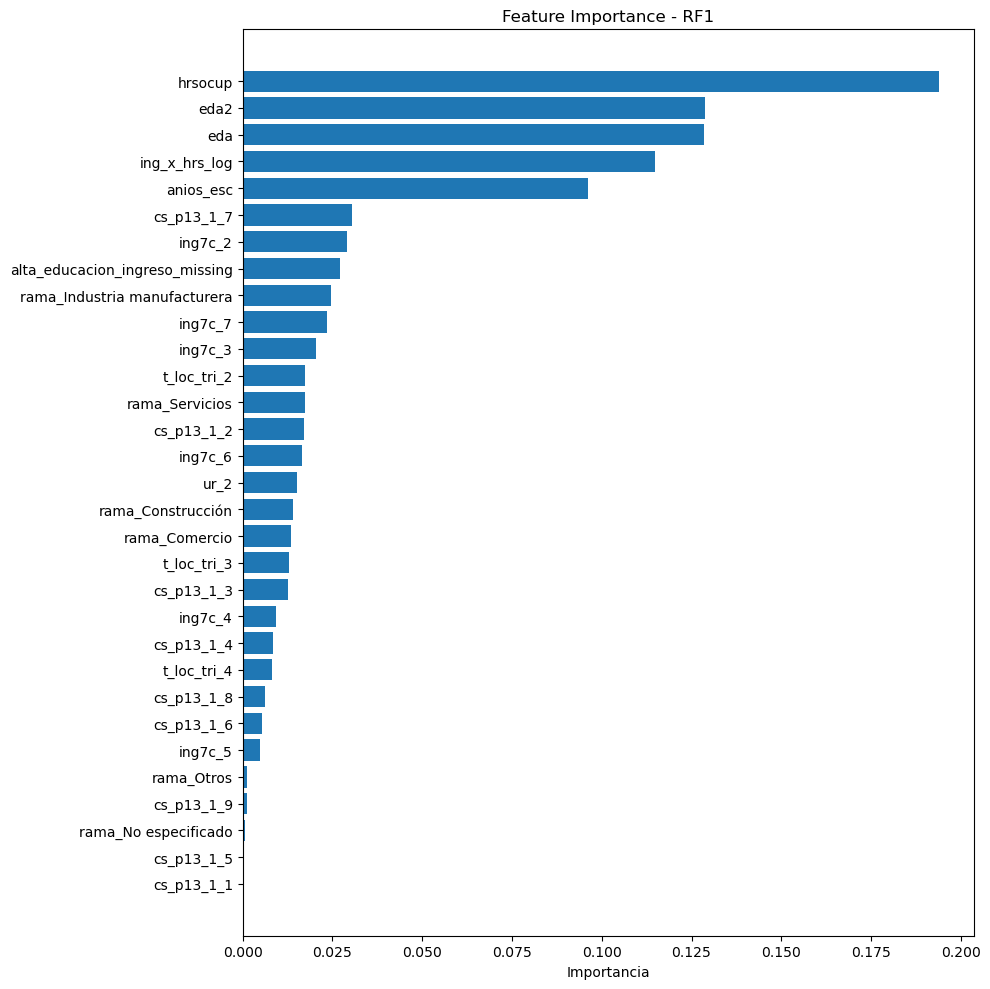

In [168]:
import pandas as pd
import matplotlib.pyplot as plt

# Feature importance del RF1
importances = rf1_sinc.feature_importances_
features = X_train.columns

# Crear df ordenado
df_importance = pd.DataFrame({
    'feature': features,
    'importance': importances
}).sort_values('importance', ascending=False).reset_index(drop=True)

print("=== Feature Importance RF1 ===")
print(df_importance.to_string())

# Graficar
plt.figure(figsize=(10, 10))
plt.barh(df_importance['feature'][::-1], df_importance['importance'][::-1])
plt.xlabel('Importancia')
plt.title('Feature Importance - RF1')
plt.tight_layout()
plt.show()

In [169]:
# Variables a eliminar
cols_eliminar_rf = ['eda2', 'rama_Otros', 'rama_No especificado', 
                    'cs_p13_1_9', 'cs_p13_1_5', 'cs_p13_1_1']

# Crear datasets reducidos
X_train_red = X_train.drop(columns=cols_eliminar_rf)
X_test_red = X_test.drop(columns=cols_eliminar_rf)

print(f"Features originales: {X_train.shape[1]}")
print(f"Features reducidas: {X_train_red.shape[1]}")
print(f"\nFeatures finales:")
print(X_train_red.columns.tolist())

# RF reducido
rf1_red = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf1_red.fit(X_train_red, y_train)

# Predicciones
y_pred_rf1_red = rf1_red.predict(X_test_red)
y_prob_rf1_red = rf1_red.predict_proba(X_test_red)[:, 1]

# Métricas
print("\n=== RF1 Reducido ===")
print(classification_report(y_test, y_pred_rf1_red, target_names=['Formal', 'Informal']))
print("=== Matriz de Confusión ===")
print(confusion_matrix(y_test, y_pred_rf1_red))
print(f"\nAUC-ROC: {roc_auc_score(y_test, y_prob_rf1_red):.4f}")

Features originales: 31
Features reducidas: 25

Features finales:
['eda', 'alta_educacion_ingreso_missing', 'anios_esc', 'hrsocup', 'ing_x_hrs_log', 't_loc_tri_2', 't_loc_tri_3', 't_loc_tri_4', 'cs_p13_1_2', 'cs_p13_1_3', 'cs_p13_1_4', 'cs_p13_1_6', 'cs_p13_1_7', 'cs_p13_1_8', 'ur_2', 'rama_Comercio', 'rama_Construcción', 'rama_Industria manufacturera', 'rama_Servicios', 'ing7c_2', 'ing7c_3', 'ing7c_4', 'ing7c_5', 'ing7c_6', 'ing7c_7']

=== RF1 Reducido ===
              precision    recall  f1-score   support

      Formal       0.75      0.78      0.76      1181
    Informal       0.78      0.75      0.76      1242

    accuracy                           0.76      2423
   macro avg       0.76      0.76      0.76      2423
weighted avg       0.76      0.76      0.76      2423

=== Matriz de Confusión ===
[[922 259]
 [315 927]]

AUC-ROC: 0.8426


## Cross validation

Validacion de overfitting para modelo RF1 (estandarizacion) despues de reducción de variables con Feature Importance.

In [171]:
from sklearn.model_selection import cross_val_score, StratifiedKFold

# Estrategia de validación cruzada
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Cross-validation con AUC-ROC
cv_auc = cross_val_score(
    rf1_red, 
    X_train_red, y_train,
    cv=cv,
    scoring='roc_auc',
    n_jobs=-1
)

# Cross-validation con accuracy
cv_acc = cross_val_score(
    rf1_red,
    X_train_red, y_train,
    cv=cv,
    scoring='accuracy',
    n_jobs=-1
)

print("=== Cross-Validation RF1 Reducido (5 folds) ===")
print(f"\nAUC-ROC por fold: {cv_auc.round(4)}")
print(f"AUC-ROC media:    {cv_auc.mean():.4f}")
print(f"AUC-ROC std:      {cv_auc.std():.4f}")

print(f"\nAccuracy por fold: {cv_acc.round(4)}")
print(f"Accuracy media:    {cv_acc.mean():.4f}")
print(f"Accuracy std:      {cv_acc.std():.4f}")

print(f"\n=== Comparación train vs test ===")
print(f"AUC-ROC CV (train): {cv_auc.mean():.4f} ± {cv_auc.std():.4f}")
print(f"AUC-ROC test:       {roc_auc_score(y_test, y_prob_rf1_red):.4f}")

=== Cross-Validation RF1 Reducido (5 folds) ===

AUC-ROC por fold: [0.8417 0.8574 0.8443 0.849  0.84  ]
AUC-ROC media:    0.8465
AUC-ROC std:      0.0062

Accuracy por fold: [0.758  0.7766 0.7719 0.7693 0.7506]
Accuracy media:    0.7653
Accuracy std:      0.0095

=== Comparación train vs test ===
AUC-ROC CV (train): 0.8465 ± 0.0062
AUC-ROC test:       0.8426


Los modelos se mantienen con metricas de validacion constante, AUC-ROC Y Accuracy no tienen variacion amplia.


In [173]:
import shap

In [174]:
# Coeficientes de la RL
coef_df = pd.DataFrame({
    'feature': X_train.columns,
    'coeficiente': rl_sinc.coef_[0]
}).sort_values('coeficiente', ascending=False)

print(coef_df.to_string())

                           feature  coeficiente
29                         ing7c_6     3.523337
5                             eda2     0.771744
22            rama_No especificado     0.504886
10                      cs_p13_1_2     0.397380
8                      t_loc_tri_4     0.355059
11                      cs_p13_1_3     0.287698
7                      t_loc_tri_3     0.284996
4                    ing_x_hrs_log     0.201065
15                      cs_p13_1_7     0.177932
20               rama_Construcción     0.147532
12                      cs_p13_1_4     0.097102
18                            ur_2     0.080710
14                      cs_p13_1_6     0.064159
6                      t_loc_tri_2    -0.054338
30                         ing7c_7    -0.150932
16                      cs_p13_1_8    -0.174490
17                      cs_p13_1_9    -0.249931
3                          hrsocup    -0.259746
9                       cs_p13_1_1    -0.410449
13                      cs_p13_1_5    -0

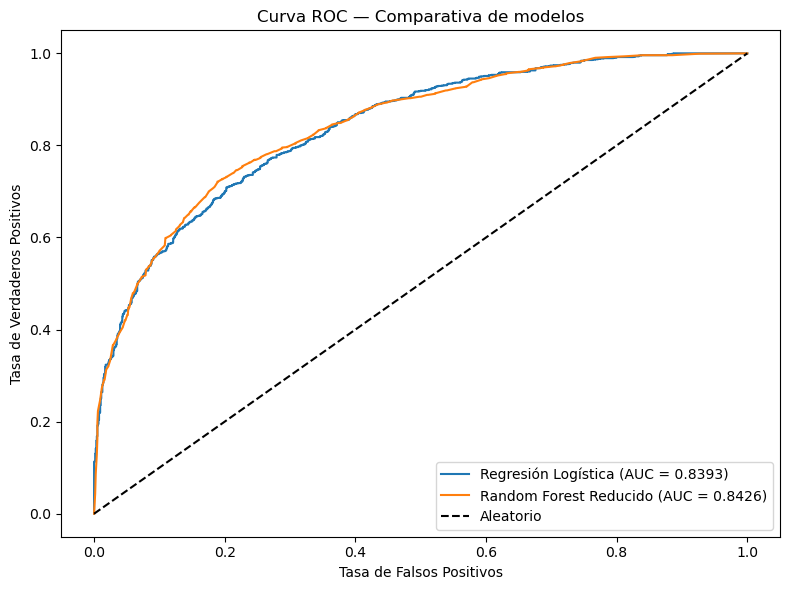

In [175]:
from sklearn.metrics import roc_curve

fpr, tpr, _ = roc_curve(y_test, y_prob)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf1_red)

plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, label=f'Regresión Logística (AUC = 0.8393)')
plt.plot(fpr_rf, tpr_rf, label=f'Random Forest Reducido (AUC = 0.8426)')
plt.plot([0,1],[0,1], 'k--', label='Aleatorio')
plt.xlabel('Tasa de Falsos Positivos')
plt.ylabel('Tasa de Verdaderos Positivos')
plt.title('Curva ROC — Comparativa de modelos')
plt.legend()
plt.tight_layout()
plt.show()

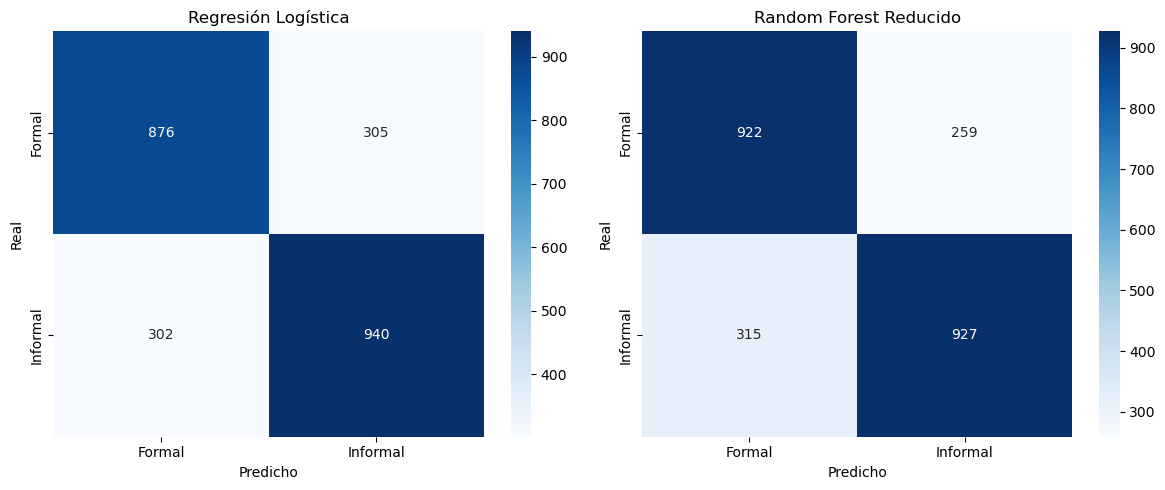

In [176]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, cm, title in zip(axes,
    [confusion_matrix(y_test, y_pred), confusion_matrix(y_test, y_pred_rf1_red)],
    ['Regresión Logística', 'Random Forest Reducido']):
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Formal','Informal'],
                yticklabels=['Formal','Informal'])
    ax.set_title(title)
    ax.set_ylabel('Real')
    ax.set_xlabel('Predicho')

plt.tight_layout()
plt.show()

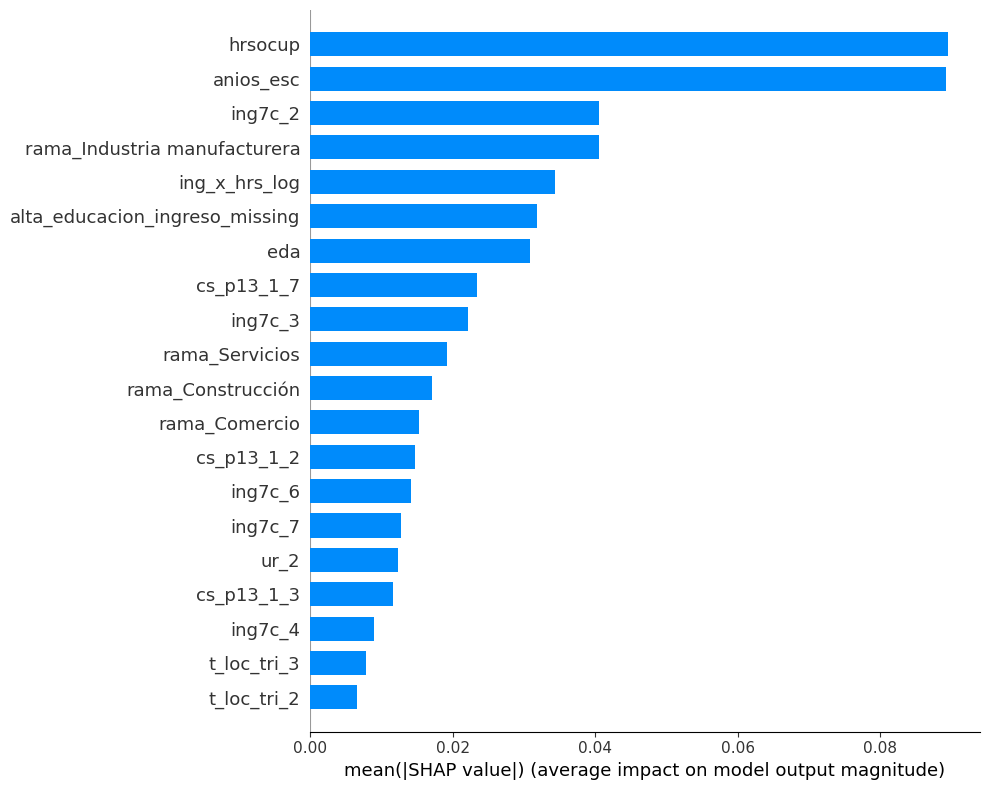

In [177]:
import shap

# Usar muestra pequeña para que corra rápido
X_sample = X_test_red.sample(500, random_state=42)

explainer = shap.TreeExplainer(rf1_red)
shap_values = explainer.shap_values(X_sample)

shap_informal = shap_values[:, :, 1]

shap.summary_plot(shap_informal, X_sample, plot_type="bar", plot_size=(10, 8))

In [178]:
print(X_train.columns.tolist())

['eda', 'alta_educacion_ingreso_missing', 'anios_esc', 'hrsocup', 'ing_x_hrs_log', 'eda2', 't_loc_tri_2', 't_loc_tri_3', 't_loc_tri_4', 'cs_p13_1_1', 'cs_p13_1_2', 'cs_p13_1_3', 'cs_p13_1_4', 'cs_p13_1_5', 'cs_p13_1_6', 'cs_p13_1_7', 'cs_p13_1_8', 'cs_p13_1_9', 'ur_2', 'rama_Comercio', 'rama_Construcción', 'rama_Industria manufacturera', 'rama_No especificado', 'rama_Otros', 'rama_Servicios', 'ing7c_2', 'ing7c_3', 'ing7c_4', 'ing7c_5', 'ing7c_6', 'ing7c_7']


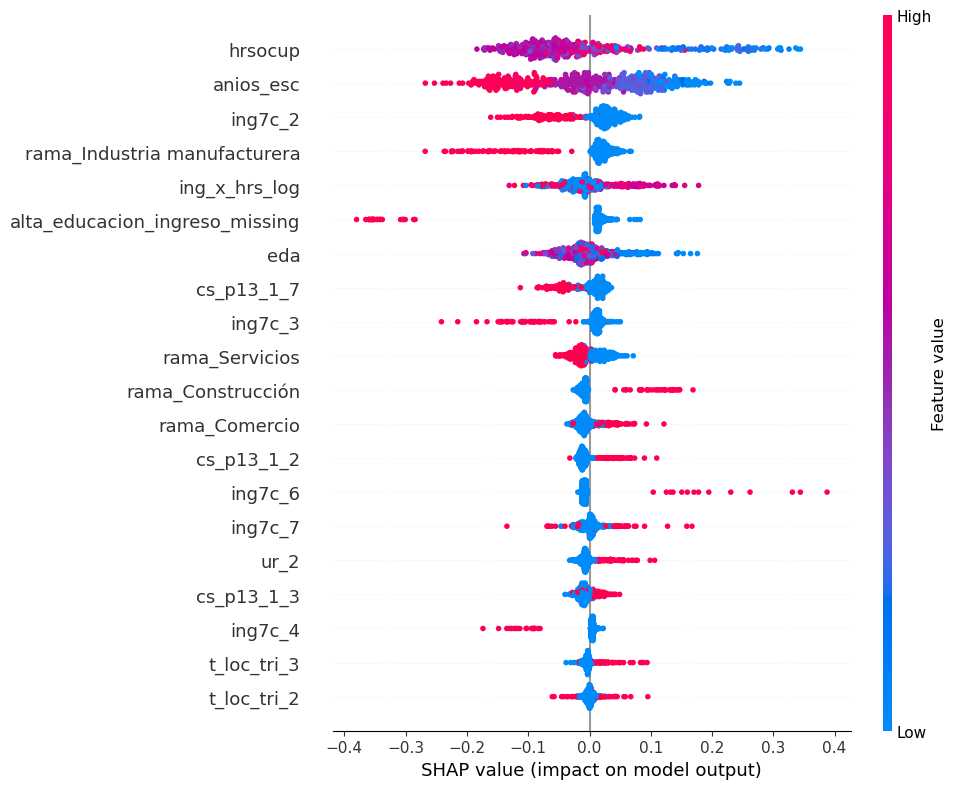

In [231]:
shap.summary_plot(shap_informal, X_sample, plot_size=(10, 8))